In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV

In [2]:
df=pd.read_csv("CKD.csv")
df=pd.get_dummies(df,drop_first=True).astype(int)

indep = df.drop('classification_yes', axis=1)
dep = df['classification_yes']
df.head()

,age,bp,al,su,bgr,bu,sc,sod,pot,hrmo,...,pc_normal,pcc_present,ba_present,htn_yes,dm_yes,cad_yes,appet_yes,pe_yes,ane_yes,classification_yes
0,2,76,3,0,148,57,3,137,4,12,...,0,0,0,0,0,0,1,1,0,1
1,3,76,2,0,148,22,0,137,4,10,...,1,0,0,0,0,0,1,0,0,1
2,4,76,1,0,99,23,0,138,4,12,...,1,0,0,0,0,0,1,0,0,1
3,5,76,1,0,148,16,0,138,3,8,...,1,0,0,0,0,0,1,0,1,1
4,5,50,0,0,148,25,0,137,4,11,...,1,0,0,0,0,0,1,0,0,1


In [3]:
X_train, X_test, y_train, y_test = train_test_split(indep, dep, test_size=0.3, random_state=0)

In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

gsv = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
gsv.fit(X_train, y_train)
gsv.best_params_

{'criterion': 'gini',
 'max_depth': 10,
 'min_samples_leaf': 1,
 'min_samples_split': 2}

In [6]:
decisionTreeClassifier = DecisionTreeClassifier(**gsv.best_params_)
decisionTreeClassifier.fit(X_train, y_train)
y_pred = decisionTreeClassifier.predict(X_test)

In [7]:
print(classification_report(y_test, y_pred))
cf = confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.96      0.98      0.97        45
           1       0.99      0.97      0.98        75

    accuracy                           0.97       120
   macro avg       0.97      0.98      0.97       120
weighted avg       0.98      0.97      0.98       120



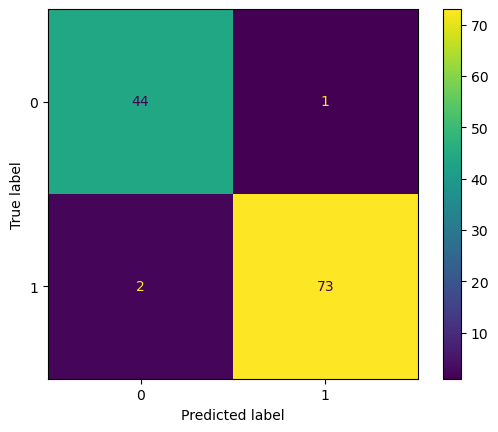

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay(cf).plot()